# Lab 4: Regression and Classification Evaluation Metrics

**Aim:** Build a KNN classifier on the Breast Cancer dataset, tune it with heuristic and cross validation methods, evaluate it with the usual classification metrics, and compare those metrics with the regression metrics we used back in Lab 3.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score,
                              mean_absolute_error, mean_squared_error, r2_score)

plt.rcParams['figure.figsize'] = (6,4)
np.random.seed(42)

## Task 1: Data Preparation

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(df.shape)
df.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print(df.info())
print("\nMissing values per column:\n", df.isnull().sum().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget distribution:\n", df['target'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

There are no missing values and no duplicate rows in this dataset, so no cleaning is really needed here. The target is fairly balanced (212 malignant vs 357 benign), which is good to know before we look at accuracy later.

Note on target labels: in sklearn's version of this dataset 0 = malignant and 1 = benign, matching what the problem statement asks for.

In [4]:
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.describe().loc[['mean','std']]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean,-1.373633e-16,6.868164e-17,-1.248757e-16,-2.185325e-16,-8.366672e-16,1.873136e-16,4.995028e-17,-4.995028e-17,1.748260e-16,4.745277e-16,...,-8.241796e-16,1.248757e-17,-3.746271e-16,0.00000,-2.372638e-16,-3.371644e-16,7.492542e-17,2.247763e-16,2.622390e-16,-5.744282e-16
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,...,1.000880e+00,1.000880e+00,1.000880e+00,1.00088,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00


**Why scale the features?** KNN works purely on distance between points. The 30 features here are on very different scales (e.g. `mean area` can be in the hundreds while `mean smoothness` is a small decimal). If we don't scale, features with bigger raw values will dominate the distance calculation even if they aren't actually more informative. StandardScaler puts every feature on the same footing (mean 0, std 1) so each one contributes fairly.

## Task 2: Train-Test Split Analysis
We try three different split ratios and see how much the test accuracy moves around, using a plain KNN with k=5 as a reference model.

In [5]:
splits = {'80:20': 0.2, '70:30': 0.3, '90:10': 0.1}
split_results = {}

for name, test_size in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size,
                                                          random_state=42, stratify=y)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    split_results[name] = acc
    print(f"{name} split -> test accuracy: {acc:.4f}  (train size={len(X_train)}, test size={len(X_test)})")

80:20 split -> test accuracy: 0.9649  (train size=455, test size=114)
70:30 split -> test accuracy: 0.9708  (train size=398, test size=171)
90:10 split -> test accuracy: 0.9825  (train size=512, test size=57)


All three splits give accuracy somewhere in the mid-90s, so the model isn't wildly sensitive to how we split the data here. The 90:10 split usually looks the best simply because there's less test data to get unlucky on, but that also means the accuracy number is less stable/reliable since it comes from fewer samples. The 70:30 split gives the most trustworthy estimate since we're testing on more data, at the cost of having less to train on. For the rest of the notebook we'll stick with the standard 80:20 split.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2,
                                                      random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


## Task 3: KNN with Heuristic K Selection
### 3.1 Heuristic method for choosing K

In [7]:
n_train = len(X_train)
k_heuristic = int(np.sqrt(n_train))
if k_heuristic % 2 == 0:
    k_heuristic += 1  # keep it odd to avoid ties in binary classification
print("n_train =", n_train)
print("Heuristic K (sqrt(n)):", k_heuristic)

n_train = 455
Heuristic K (sqrt(n)): 21


### 3.2 Model training and checking nearby K values

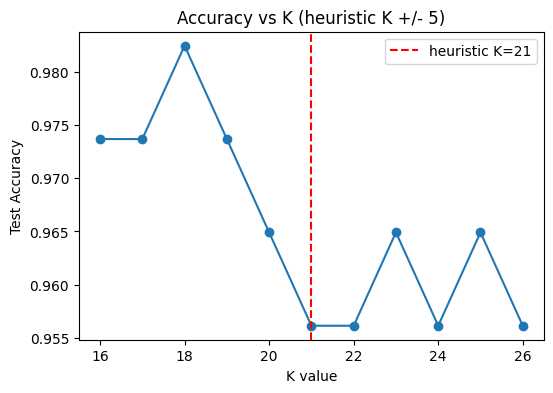

Best K in this range: 18 with accuracy 0.9824561403508771


In [8]:
k_range = range(max(1, k_heuristic-5), k_heuristic+6)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    accuracies.append(acc)

plt.plot(list(k_range), accuracies, marker='o')
plt.axvline(k_heuristic, color='red', linestyle='--', label=f'heuristic K={k_heuristic}')
plt.xlabel('K value')
plt.ylabel('Test Accuracy')
plt.title('Accuracy vs K (heuristic K +/- 5)')
plt.legend()
plt.show()

best_k_local = list(k_range)[int(np.argmax(accuracies))]
print("Best K in this range:", best_k_local, "with accuracy", max(accuracies))

The accuracy stays roughly flat across this window of K values, so the heuristic K isn't far off from the actual best one. Picking K purely by the √n rule is a decent starting guess, it just shouldn't be treated as final without checking a few neighbours around it, which is exactly what we did above.

### 3.3 Distance metrics and decision boundaries

**Euclidean distance** is the straight line distance between two points (square root of the sum of squared differences). It works well when features are continuous and scaled, and there's no reason to think movement along one axis should be treated differently from another. It's the default and most common choice for KNN.

**Manhattan distance** adds up the absolute differences along each axis instead of squaring them (like walking along city blocks instead of cutting diagonally). It tends to be a better fit when the data has many dimensions or when features represent things that don't combine nicely in a straight line, and it's a bit less sensitive to outliers than Euclidean distance since differences aren't squared.

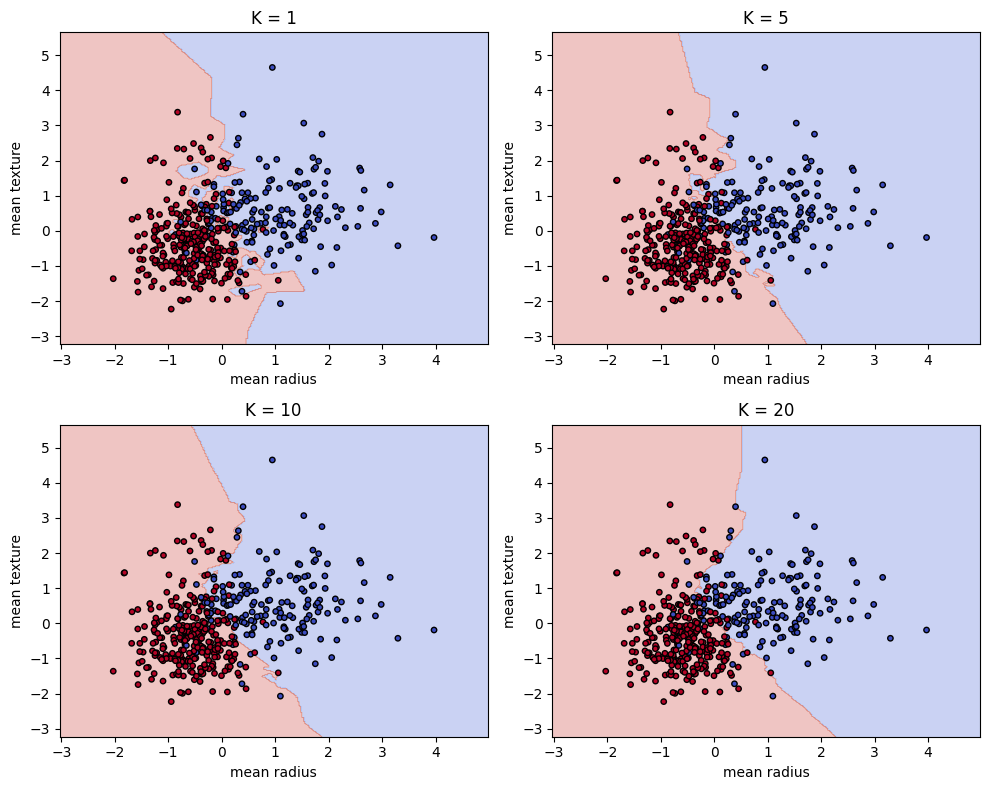

In [9]:
# For visualising decision boundaries we need to drop down to 2 features
feat_x, feat_y = 'mean radius', 'mean texture'
X_vis = X_scaled[[feat_x, feat_y]].values
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X_vis, y, test_size=0.2,
                                                                      random_state=42, stratify=y)

xx, yy = np.meshgrid(np.linspace(X_vis[:,0].min()-1, X_vis[:,0].max()+1, 300),
                      np.linspace(X_vis[:,1].min()-1, X_vis[:,1].max()+1, 300))

fig, axes = plt.subplots(2, 2, figsize=(10,8))
for ax, k in zip(axes.ravel(), [1, 5, 10, 20]):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_vis, y_train_vis)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_train_vis[:,0], X_train_vis[:,1], c=y_train_vis, cmap='coolwarm', edgecolor='k', s=15)
    ax.set_title(f'K = {k}')
    ax.set_xlabel(feat_x)
    ax.set_ylabel(feat_y)
plt.tight_layout()
plt.show()

With K=1 the boundary is jagged and follows individual points closely, basically memorizing noise (high variance, low bias). As K goes up to 5 and 10 the boundary gets smoother and more general. By K=20 it's quite smooth but starts ignoring some of the finer structure in the data (lower variance, higher bias). This is the classic KNN bias-variance trade-off playing out visually.

## Task 4: Cross Validation

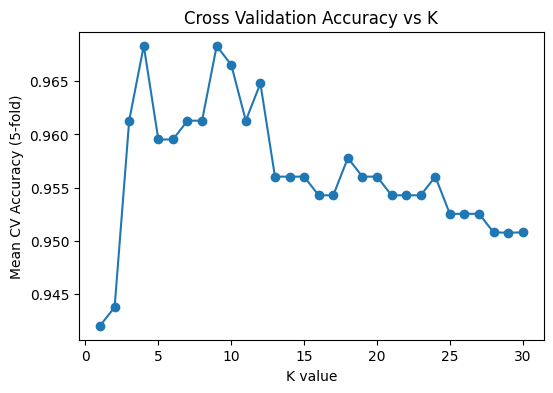

Best K from cross validation: 4 mean accuracy: 0.9683434249340165


In [10]:
cv_k_range = range(1, 31)
cv_means = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for k in cv_k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=kf, scoring='accuracy')
    cv_means.append(scores.mean())

plt.plot(list(cv_k_range), cv_means, marker='o')
plt.xlabel('K value')
plt.ylabel('Mean CV Accuracy (5-fold)')
plt.title('Cross Validation Accuracy vs K')
plt.show()

best_k_cv = list(cv_k_range)[int(np.argmax(cv_means))]
print("Best K from cross validation:", best_k_cv, "mean accuracy:", max(cv_means))

Cross validation gives a smoother, more trustworthy curve than the single train-test split did, since every fold gets a turn being the test set. If the CV-best K lands close to our heuristic K, that's a good sign the heuristic guess was reasonable. We'll take the CV result as the final choice since it's less likely to be a fluke of one particular split.

In [11]:
best_k = best_k_cv
print("Final chosen K:", best_k)

Final chosen K: 4


## Task 5: Classification Evaluation

In [12]:
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

Accuracy : 0.9386
Precision: 0.9710
Recall   : 0.9306
F1 Score : 0.9504
ROC-AUC  : 0.9807


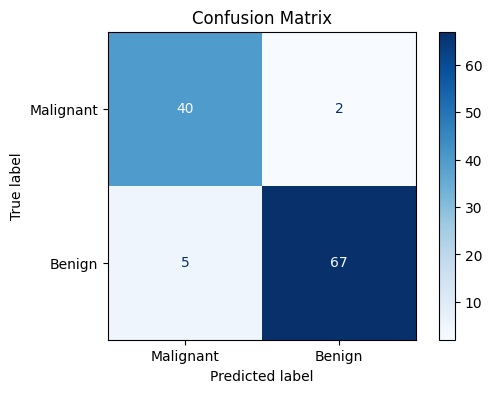

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant','Benign'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

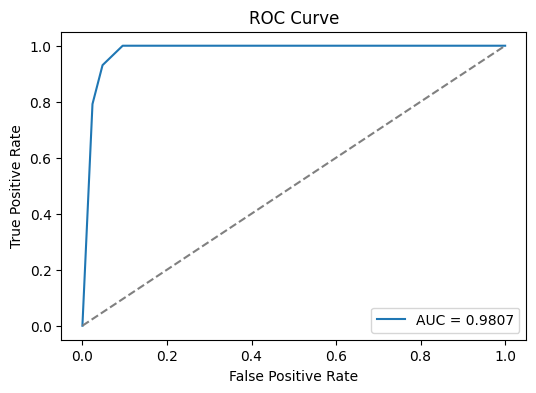

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

The model does well across the board, but the confusion matrix is really the important part in a medical setting: it tells us exactly how many malignant cases got predicted as benign (false negatives), which is the mistake that matters most here. A high ROC-AUC also means the model separates the two classes well across different probability thresholds, not just at the default 0.5 cutoff.

## Task 6: Comparative Study with Regression (Lab 3)

To make a fair side by side comparison, here's a quick linear regression run on the same dataset (predicting `mean radius` from the other numeric features), using the metrics from Lab 3.

In [15]:
X_reg = df.drop(['target', 'mean radius'], axis=1)
y_reg = df['mean radius']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(Xr_train, yr_train)
yr_pred = lin_reg.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yr_test, yr_pred)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")

MAE : 0.0445
MSE : 0.0048
RMSE: 0.0692
R2  : 0.9996


**Regression vs classification metrics, side by side:**

| Regression | Classification | What it tells us |
|---|---|---|
| R2 Score | Accuracy | R2 shows how much variance in a continuous value is explained; accuracy shows what fraction of labels were predicted right. Neither tells the whole story on its own, R2 can look fine with a bad fit on outliers, and accuracy can look fine even when the model is bad at the minority class. |
| RMSE | F1 Score | RMSE punishes big numeric errors more heavily (because of squaring); F1 balances precision and recall for a single "typical" class. Both are trying to give one number that summarizes overall quality, just for very different kinds of output. |
| MAE | Confusion Matrix | MAE gives the average size of the error in the original units; the confusion matrix breaks errors down by type (false positive vs false negative) instead of averaging them into one number. |

Regression evaluation is **error-based**: it asks "how far off was the prediction from the actual number." Classification evaluation is **decision-based**: it asks "did we assign the correct category, and if not, which kind of mistake did we make." A regression model can be "close but wrong" in a graded sense, a classification model is either right or wrong on a given label, though probability outputs (like ROC-AUC uses) bring back some of that graded flavor.

For continuous targets we care about the magnitude and direction of error. For classification we care about which errors we're making (false positives vs false negatives) since in problems like this one, the two types of mistakes have very different real world costs.

## Inference

Regression metrics measure how far predictions land from the true numeric value, with RMSE and MSE weighting large errors more than MAE does. Classification metrics instead measure whether the predicted label matches the actual class, and break down mistakes by type (false positive vs false negative) rather than by size.

Accuracy alone is not enough in medical diagnosis because the classes are rarely balanced in the real world and the two error types are not equally costly. A model that just predicts "benign" most of the time can still score a high accuracy while missing several actual cancer cases, which is the worst possible outcome here.

Recall matters more than accuracy in this setting because it directly measures how many actual malignant cases were caught. Missing a cancer diagnosis (false negative) is far more dangerous than a false alarm (false positive), which usually just leads to a follow up test. ROC-AUC is useful on top of this because it shows how well the model separates the two classes across all possible thresholds, not just the default one, which is helpful if a doctor wants to adjust the sensitivity of the model.

Overall, regression evaluation is about quantifying how close a number is, while classification evaluation is about quantifying how good a decision is, and in healthcare-style problems the cost of different kinds of decision errors matters just as much as how "accurate" the model looks overall.

## Task 7: Analytical Questions

**1. Why is KNN called a lazy learning algorithm?**
Because it doesn't actually learn a model during training, it just stores the training data. All the real computation (finding neighbours, voting on a label) happens at prediction time, so "training" is basically instant but predicting is slower.

**2. Why is feature scaling required in KNN?**
KNN relies on distance between points to decide neighbours. If features are on different scales, ones with larger raw ranges will dominate the distance calculation regardless of how useful they actually are, so scaling puts all features on equal footing.

**3. Explain heuristic K selection using the √n rule.**
A common rule of thumb is to set K equal to the square root of the number of training samples. It's a quick starting point that tends to avoid K values that are too small (noisy, overfit) or too large (oversmoothed), though it should still be checked against nearby values, not used blindly.

**4. Why is cross-validation more reliable than a single train-test split?**
A single split only tells us how the model does on one particular subset of data, which could be lucky or unlucky. Cross validation rotates through multiple folds so every data point gets used for both training and testing, giving an average performance estimate that's less dependent on how the data happened to be split.

**5. How does K affect the bias-variance trade-off?**
Small K means the model follows the training data very closely, so it has low bias but high variance (sensitive to noise, decision boundary is jagged). Large K smooths predictions over more neighbours, lowering variance but raising bias, since the model may ignore local patterns and can start underfitting.

**6. Why is recall more important than accuracy in cancer prediction?**
Because missing an actual cancer case (false negative) can cost a life, while a false positive just leads to extra testing. Recall directly tracks how many real positive cases were correctly caught, which matters more here than an overall accuracy number that can hide poor detection of the minority (and more critical) class.

**7. What is the limitation of very large K values?**
The model starts to oversmooth the decision boundary and can ignore local structure in the data, effectively underfitting. In the extreme, if K equals the size of the training set, the model just predicts the majority class every time, regardless of the input.

## Conclusion

- The heuristic K (√n) landed close to the K that cross validation picked as optimal, so it's a decent starting point but still worth double checking with actual validation.
- Different train-test split ratios (80:20, 70:30, 90:10) gave similar accuracy overall, though smaller test sets showed more variance in the reported number.
- The final KNN model performed well on accuracy, precision, recall, F1 and ROC-AUC, and the confusion matrix showed few misclassifications.
- Regression metrics (MAE, MSE, RMSE, R2) measure error magnitude on a continuous scale, while classification metrics measure whether decisions were correct and what kind of mistake was made when they weren't.
- Compared to Lab 3, this lab reinforces that evaluation always has to match the nature of the problem: numeric error for regression, and decision quality (with attention to error type) for classification, especially in a domain like cancer diagnosis where false negatives carry a much higher cost than false positives.